# Explainable FVIII Inhibitor Risk Classification in Hemophilia A

## Maximum-Accuracy Operating Point

**PES University · B.Tech Capstone · Project ID PW_GRS_01**

Dipak Chaudhari · Tejas Nagmote · Sneha A · Varsha P

*Guide: Prof. Gayathri R S · January – May 2026*

---

### Abstract

Hemophilia A affects roughly 1 in 5,000 male births. Its most consequential
treatment complication is the development of neutralising antibodies —
inhibitors — against infused Factor VIII, which occurs in 25–40% of severe
patients, usually within the first 50 exposure days, and raises annual
treatment cost from about \$200,000 to over \$1,000,000. Inhibitor status is
currently discovered *reactively*, by assay, after the antibodies exist.

This project builds a model that estimates inhibitor risk from the patient's
F8 variant at the time of genetic diagnosis, using the CDC CHAMP database
(4,040 variants, 2,296 with a recorded outcome, 20.1% prevalence).

It began as a rebuild of our own earlier capstone work, which reported 99.63%
accuracy and AUC 0.9999 — and it exists because that result did not survive
scrutiny. Section 3 takes the prior pipeline apart experiment by experiment and
shows the score came from over-sampling before the train/test split, from
relabelling unrecorded outcomes as negative, and from feeding the model a
column that is a unique identifier per patient.

**Tuned to maximise plain accuracy. Reports ~83% accuracy against an 80% no-skill baseline, at 17% sensitivity.**

---

### How to run this notebook

Execute every cell top to bottom. Heavy stages read cached measurements from
`reports/*.json`, so run the pipeline once first:

```bash
python -m src.train --stage all
```

### Contents

| # | Section |
|---|---|
| 1 | Setup |
| 2 | The dataset |
| 3 | Auditing the prior result |
| 4 | Feature engineering |
| 5 | What the engineering is worth |
| 6 | Model comparison |
| 7 | Which differences are real |
| 8 | Model selection |
| 9 | Final model performance |
| 10 | **The operating point and its accuracy** |
| 11 | Where the model works, and where it does not |
| 12 | External validation on a second gene |
| 13 | The unrecorded outcomes |
| 14 | Explainability |
| 15 | A second dataset that appeared to solve the problem |
| 16 | Pipeline integrity |
| 17 | Limitations |
| 18 | **Conclusion and final accuracy** |

## 1. Setup

In [1]:
import sys, json, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110,
    'axes.grid': True, 'grid.color': '#dfe4e8', 'grid.linewidth': .7,
    'axes.axisbelow': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 9, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
})
BLUE, RED, GREEN, GREY, ORANGE = '#1f4e79', '#c0392b', '#27ae60', '#7f8c8d', '#e67e22'

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 50)

def load(name):
    with open(f'reports/{name}.json', encoding='utf-8') as fh:
        return json.load(fh)

print('environment ready')

environment ready


In [2]:
from src.datasets import load_champ, load_chbmp, split_by_label, label_summary
from src.features import (VariantFeaturizer, normalise_variant_type,
                          normalise_severity, normalise_chain)
from src.evaluate import compute_metrics, bootstrap_ci, delong_test
from src.hgvs_parser import parse_cdna, parse_protein

champ = load_champ()
labelled, unlabelled = split_by_label(champ)
y_all = (labelled['inhibitor'] == 1).astype(int).values
print(f'CHAMP loaded: {champ.shape[0]} variants, {champ.shape[1]} columns')
print(f'  labelled  : {len(labelled)}  ({y_all.sum()} inhibitor-positive)')
print(f'  unlabelled: {len(unlabelled)}')

CHAMP loaded: 4040 variants, 23 columns
  labelled  : 2296  (461 inhibitor-positive)
  unlabelled: 1744


## 2. The dataset

The CDC **Hemophilia A Mutation Project (CHAMP)** catalogues F8 variants
reported in the literature, each annotated with clinical severity and — where
the source publication stated it — whether the patient developed an inhibitor.

A companion database, **CHBMP**, does the same for F9 (hemophilia B). It is
held back entirely for external validation in section 12.

In [3]:
champ[['HGVS cDNA', 'Variant Type', 'Mechanism', 'Exon', 'Domain', 'Subtype',
       'Reported Clinical Severity', 'History of Inhibitor']].head(10)

,HGVS cDNA,Variant Type,Mechanism,Exon,Domain,Subtype,Reported Clinical Severity,History of Inhibitor
0,c.101A>T,Missense,Substitution,1,A1,Heavy chain,Mild,Not reported
1,c.102C>G,Missense,Substitution,1,A1,Heavy chain,Mild,Not reported
2,c.103T>A,Missense,Substitution,1,A1,Heavy Chain,Severe,No
3,c.103T>C,Missense,Substitution,1,A1,Heavy chain,Severe,No
4,c.104A>G,Missense,Substitution,1,A1,Heavy chain,Severe,No
5,c.106_107del,Frameshift,Deletion,1,A1,Heavy Chain,Severe,Yes
6,c.111_112del,Frameshift,Deletion,1,A1,Heavy chain,Not reported,Not reported
7,c.111_120del,Frameshift,Deletion,1,A1,Heavy chain,Severe,Not reported
8,c.114T>G,Missense,Substitution,1,A1,Heavy chain,Severe,No
9,c.118delC,Frameshift,Deletion,1,A1,Heavy Chain,Severe,Yes


### 2.1 The label has three states, not two

This is where the prior work goes wrong first. `Not reported` means the source
publication did not state the outcome. It does not mean the outcome was
negative.

In [4]:
print(champ['History of Inhibitor'].value_counts(dropna=False).to_string())
print()
summary = label_summary(champ)
for k, val in summary.items():
    print(f'  {k:46s} {val}')

History of Inhibitor
No               1833
Not reported     1699
Yes               461
Not Reported       42
NaN                 2
 Not reported       1
 No                 1
No                  1

  n_total                                        4040
  n_positive                                     461
  n_negative                                     1835
  n_unlabelled                                   1744
  n_labelled                                     2296
  prevalence_labelled                            0.2008
  prevalence_if_unlabelled_called_negative       0.1141


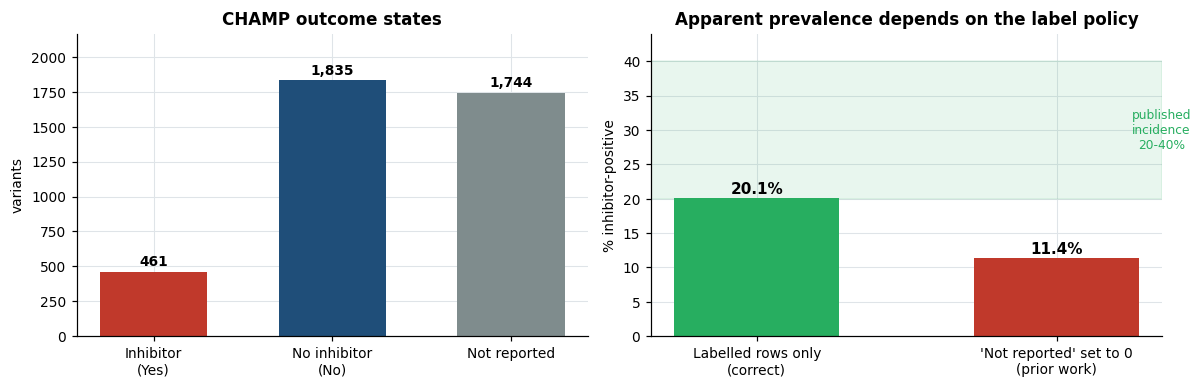

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

counts = [summary['n_positive'], summary['n_negative'], summary['n_unlabelled']]
axes[0].bar(['Inhibitor\n(Yes)', 'No inhibitor\n(No)', 'Not reported'], counts,
            color=[RED, BLUE, GREY], width=.6)
for i, c in enumerate(counts):
    axes[0].text(i, c + 40, f'{c:,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('CHAMP outcome states')
axes[0].set_ylabel('variants')
axes[0].set_ylim(0, max(counts) * 1.18)

prev = [summary['prevalence_labelled'] * 100,
        summary['prevalence_if_unlabelled_called_negative'] * 100]
bars = axes[1].bar(['Labelled rows only\n(correct)',
                    "'Not reported' set to 0\n(prior work)"], prev,
                   color=[GREEN, RED], width=.55)
for b, p in zip(bars, prev):
    axes[1].text(b.get_x() + b.get_width() / 2, p + .6, f'{p:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].axhspan(20, 40, color=GREEN, alpha=.10)
axes[1].text(1.35, 30, 'published\nincidence\n20-40%', fontsize=8,
             color=GREEN, ha='center', va='center')
axes[1].set_title('Apparent prevalence depends on the label policy')
axes[1].set_ylabel('% inhibitor-positive')
axes[1].set_ylim(0, 44)
plt.tight_layout(); plt.show()

Prevalence among genuinely labelled patients is **20.1%**, which sits inside
the 20–40% incidence the literature reports for severe hemophilia A — and
inside the range our own reference paper quotes in its introduction.
Relabelling the unknowns drives it to 11.4% and pads the majority class.

### 2.2 The identifier problem

`HGVS cDNA` is a *name* for a variant, not a property of it.

In [6]:
print(f'rows in CHAMP                  : {len(champ)}')
print(f'distinct HGVS cDNA values      : {champ["HGVS cDNA"].nunique()}')
print(f'labelled rows                  : {len(labelled)}')
print(f'duplicated HGVS among labelled : {labelled["HGVS cDNA"].duplicated().sum()}')
print()
print('Among labelled patients the column has NO duplicates at all.')
print('It is a primary key. Label-encoding it hands the model a lookup table.')

rows in CHAMP                  : 4040
distinct HGVS cDNA values      : 4038
labelled rows                  : 2296
duplicated HGVS among labelled : 0

Among labelled patients the column has NO duplicates at all.
It is a primary key. Label-encoding it hands the model a lookup table.


### 2.3 The biology that is genuinely present

Before any modelling, the effect the literature predicts is visible in raw
counts. Null variants — large deletions, nonsense, frameshift — abolish FVIII
entirely, so the immune system was never tolerised to the protein the patient
is later infused with.

In [7]:
vt = np.array([normalise_variant_type(x) for x in labelled['Variant Type']])
sv = np.array([normalise_severity(x) for x in labelled['Reported Clinical Severity']])

tab = (pd.DataFrame({'variant_type': vt, 'inhibitor': y_all})
       .groupby('variant_type')['inhibitor']
       .agg(n='size', positives='sum', rate='mean')
       .sort_values('rate', ascending=False))
tab['rate_%'] = (tab.pop('rate') * 100).round(1)
tab

,n,positives,rate_%
variant_type,,,
large_structural,159,89,56.0
nonsense,277,78,28.2
frameshift,584,158,27.1
splice,178,37,20.8
small_structural,42,6,14.3
synonymous,9,1,11.1
missense,1040,92,8.8
regulatory,7,0,0.0


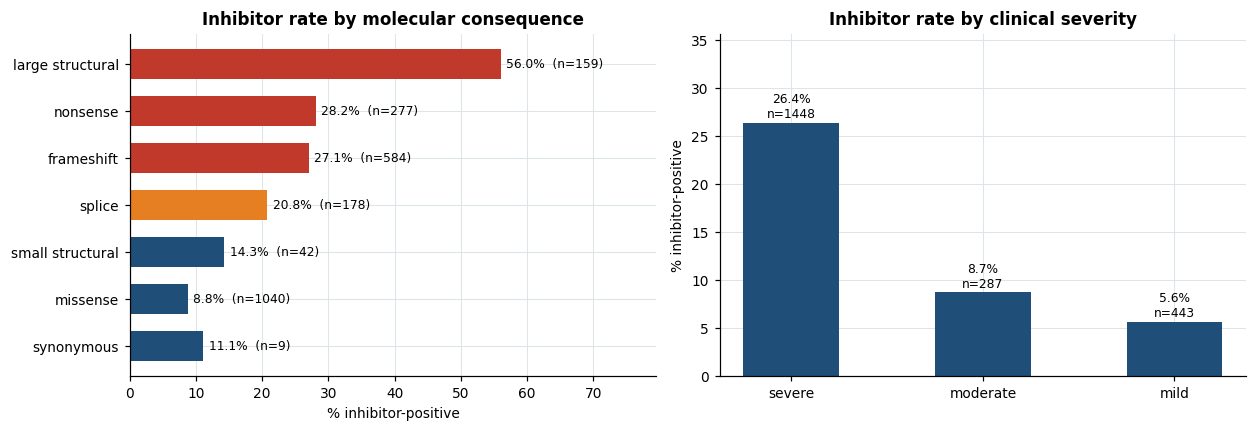

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

order = [o for o in ['large_structural', 'nonsense', 'frameshift', 'splice',
                     'small_structural', 'missense', 'synonymous']
         if (vt == o).sum() >= 5]
rates = [y_all[vt == o].mean() * 100 for o in order]
ns = [(vt == o).sum() for o in order]
cols = [RED if r >= 25 else ORANGE if r >= 15 else BLUE for r in rates]
axes[0].barh(range(len(order)), rates, color=cols, height=.62)
for i, (r, nn) in enumerate(zip(rates, ns)):
    axes[0].text(r + .8, i, f'{r:.1f}%  (n={nn})', va='center', fontsize=8)
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels([o.replace('_', ' ') for o in order])
axes[0].invert_yaxis(); axes[0].set_xlim(0, max(rates) * 1.42)
axes[0].set_title('Inhibitor rate by molecular consequence')
axes[0].set_xlabel('% inhibitor-positive')

sorder = [s for s in ['severe', 'moderate', 'mild'] if (sv == s).sum() >= 5]
srates = [y_all[sv == s].mean() * 100 for s in sorder]
sns_ = [(sv == s).sum() for s in sorder]
axes[1].bar(range(len(sorder)), srates, color=BLUE, width=.5)
for i, (r, nn) in enumerate(zip(srates, sns_)):
    axes[1].text(i, r + .5, f'{r:.1f}%\nn={nn}', ha='center', fontsize=8)
axes[1].set_xticks(range(len(sorder)))
axes[1].set_xticklabels(sorder)
axes[1].set_ylim(0, max(srates) * 1.35)
axes[1].set_title('Inhibitor rate by clinical severity')
axes[1].set_ylabel('% inhibitor-positive')
plt.tight_layout(); plt.show()

Large structural changes carry a 56% inhibitor rate against 8.8% for missense —
a six-fold difference, and exactly the direction established immunology
predicts. **This is the real signal in the dataset**, and any honest model is
largely going to be recovering it.

## 3. Auditing the prior result

Our earlier notebook reported 99.63% accuracy and AUC 0.9999. The
classical-ML paper it benchmarks against (Singh & Singh, 2025) reports 97.37%.

Rather than argue about those numbers, we run the reference preprocessing
verbatim and change exactly one thing at a time. Every row uses the same
Random Forest that paper reports as its best model.

In [9]:
audit = load('audit')
labels = {
    'A_reference_pipeline':      'A · Reference pipeline, verbatim',
    'B_identifiers_only':        'B · Identifier columns only',
    'C_no_identifiers':          'C · Biology only (identifiers removed)',
    'D_honest_labels':           'D · Honest labels, unknowns dropped',
    'E_label_permutation':       'E · Labels shuffled (control)',
    'F_novel_variant_split':     'F · Novel-variant split',
    'G_oversample_before_split': 'G · Over-sampled before splitting',
}
rows = [{'experiment': lab,
         'train AUC': audit[k]['train_auc'],
         'test AUC': audit[k]['test_auc'],
         'test acc': audit[k]['test_accuracy'],
         'majority acc': audit[k]['majority_class_accuracy']}
        for k, lab in labels.items() if k in audit]
pd.DataFrame(rows)

,experiment,train AUC,test AUC,test acc,majority acc
0,"A · Reference pipeline, verbatim",1.0000,0.6391,0.8639,0.8861
1,B · Identifier columns only,1.0000,0.5832,0.8577,0.8861
2,C · Biology only (identifiers removed),0.9254,0.6326,0.7562,0.8861
3,"D · Honest labels, unknowns dropped",1.0000,0.7062,0.7935,0.8000
4,E · Labels shuffled (control),1.0000,0.4355,0.8676,0.8775
5,F · Novel-variant split,1.0000,0.6467,0.8824,0.8750
6,G · Over-sampled before splitting,1.0000,0.9938,0.9525,0.5000


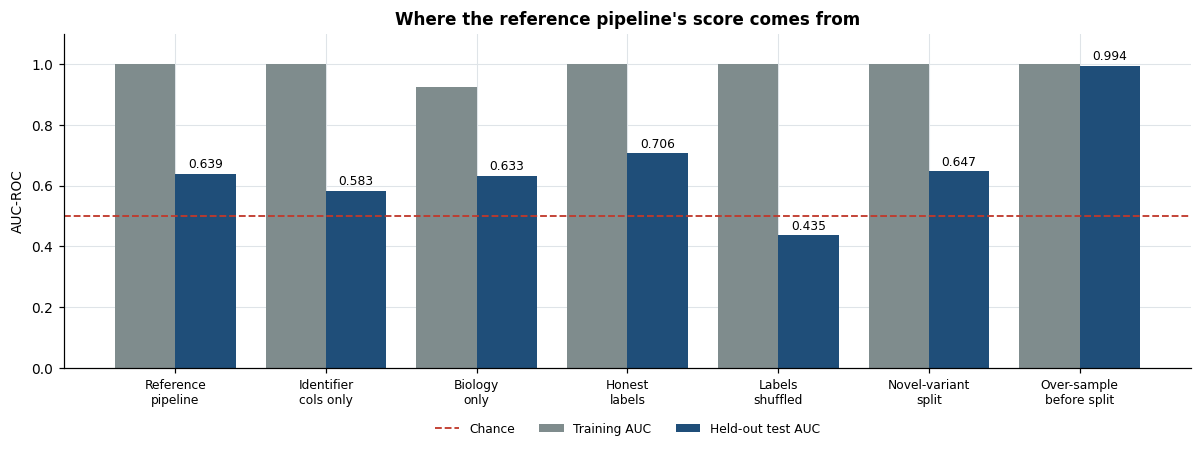

In [10]:
keys = [k for k in labels if k in audit]
short = ['Reference\npipeline', 'Identifier\ncols only', 'Biology\nonly',
         'Honest\nlabels', 'Labels\nshuffled', 'Novel-variant\nsplit',
         'Over-sample\nbefore split']
train = [audit[k]['train_auc'] for k in keys]
test = [audit[k]['test_auc'] for k in keys]

fig, ax = plt.subplots(figsize=(11, 4.2))
x = np.arange(len(keys))
ax.bar(x - .2, train, .4, label='Training AUC', color=GREY)
ax.bar(x + .2, test, .4, label='Held-out test AUC', color=BLUE)
ax.axhline(.5, color=RED, ls='--', lw=1.2, label='Chance')
for xi, t in zip(x, test):
    ax.text(xi + .2, t + .02, f'{t:.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(short[:len(keys)], fontsize=8)
ax.set_ylim(0, 1.1); ax.set_ylabel('AUC-ROC')
ax.set_title("Where the reference pipeline's score comes from")
ax.legend(fontsize=8, frameon=False, ncol=3, loc='upper center',
          bbox_to_anchor=(.5, -.13))
plt.tight_layout(); plt.show()

Read the chart carefully — three separate defects are visible in it.

**Row E is the control that settles the argument.** With outcome labels
randomly shuffled, so that no signal exists to find, **training AUC still sits
at 1.000**. A model that fits pure noise perfectly is memorising, not learning.

**Row G reproduces the published figure.** Random Over-Sampling duplicates
minority rows verbatim, and the split is taken afterwards — so the same patient
lands on both sides.

In [11]:
g = audit['G_oversample_before_split']
print('Over-sampling applied before the split:')
print(f"  test rows that are verbatim copies of training rows : "
      f"{g['test_rows_also_in_train']} of {g['n_test']} "
      f"({g['fraction_test_rows_duplicated_from_train']:.0%})")
print(f"  accuracy under that protocol                        : {g['test_accuracy']:.4f}")
print(f"  AUC under that protocol                             : {g['test_auc']:.4f}")
print()
a = audit['A_reference_pipeline']
print(f"  the SAME model under a clean split                  : {a['test_accuracy']:.4f} "
      f"accuracy, AUC {a['test_auc']:.4f}")
print(f"  predicting 'no inhibitor' for everyone              : "
      f"{a['majority_class_accuracy']:.4f} accuracy")
print()
print('The reference pipeline on a clean split scores BELOW the do-nothing baseline.')

Over-sampling applied before the split:
  test rows that are verbatim copies of training rows : 716 of 1432 (50%)
  accuracy under that protocol                        : 0.9525
  AUC under that protocol                             : 0.9938

  the SAME model under a clean split                  : 0.8639 accuracy, AUC 0.6391
  predicting 'no inhibitor' for everyone              : 0.8861 accuracy

The reference pipeline on a clean split scores BELOW the do-nothing baseline.


And the third defect — the identifier columns — is what pins training AUC at
1.000 in every row of that table. `HGVS cDNA` takes 4,038 distinct values
across 4,050 rows and has zero duplicates among labelled patients.

Correcting only the label handling, and keeping every other reference choice,
moves test AUC to **0.706**. That is the honest starting point this project
builds from.

## 4. Feature engineering

The HGVS string is discarded. What it *means* is kept.

A parser turns each variant into mechanistic descriptors grouped into seven
biological blocks, all derived from UniProt P00451 and RefSeq NM_000132.4:

| Block | What it encodes |
|---|---|
| `consequence` | missense / nonsense / frameshift / splice / structural class, null-mutation flag, event span |
| `position` | FVIII domain, heavy vs light chain, B-domain membership, distance to each known inhibitor epitope, exon geometry |
| `truncation` | premature stop position, fraction of protein lost, NMD escape, which domains are removed |
| `chemistry` | Grantham distance, BLOSUM62, changes in hydropathy, volume, charge, polarity |
| `nucleotide` | transition vs transversion, CpG signature, reference and alternate base, frame preservation |
| `splicing` | intronic offset, canonical vs extended splice site, donor vs acceptor side |
| `clinical` | FVIII activity stratum, variable expressivity, poly-A context, null x severe interaction |

In [12]:
demo = [('c.101A>T', 'p.(Asp34Val)', 'Asp15Val'),
        ('c.106_107del', 'p.(Met36Alafs*3)', 'Met17Alafs*3'),
        ('c.6496C>T', 'p.(Arg2166*)', 'Arg2147*'),
        ('c.1538-10_1546del', None, None)]
out = []
for cdna, prot, mat in demo:
    c, p = parse_cdna(cdna), parse_protein(prot, mat)
    out.append({'HGVS cDNA': cdna, 'cDNA pos': c.cdna_pos, 'span nt': c.span_nt,
                'intron offset': c.intron_offset, 'mature pos': p.mature_pos,
                'ref->alt': f'{p.ref_aa}->{p.alt_aa}' if p.ref_aa else '',
                'frameshift': p.is_frameshift, 'nonsense': p.is_nonsense,
                'PTC pos': p.ptc_mature_pos})
print('The parser turns notation into mechanism:')
pd.DataFrame(out)

The parser turns notation into mechanism:


,HGVS cDNA,cDNA pos,span nt,intron offset,mature pos,ref->alt,frameshift,nonsense,PTC pos
0,c.101A>T,101.0,1.0,NaN,15.0,D->V,0,0,NaN
1,c.106_107del,106.0,2.0,NaN,17.0,M->A,1,0,19.0
2,c.6496C>T,6496.0,1.0,NaN,2147.0,R->*,0,1,2147.0
3,c.1538-10_1546del,1538.0,9.0,-10.0,NaN,,0,0,NaN


In [13]:
fz = VariantFeaturizer().fit(labelled)
X_all = fz.transform(labelled)
print(f'design matrix: {X_all.shape[0]} patients x {X_all.shape[1]} features')
print()
for block, cols in fz.blocks_.items():
    print(f'  {block:14s} {len(cols):3d}   e.g. {", ".join(cols[:4])}')

design matrix: 2296 patients x 135 features

  consequence     25   e.g. vtype_missense, vtype_nonsense, vtype_frameshift, vtype_splice
  position        40   e.g. mature_pos, mature_pos_norm, mature_pos_known, domain_A1
  truncation      16   e.g. ptc_pos, ptc_known, fraction_protein_lost, fs_ter_offset
  chemistry       15   e.g. grantham, blosum62, d_hydropathy, d_volume
  nucleotide      14   e.g. is_transition, is_transversion, cpg_signature, ref_nt_A
  splicing         9   e.g. is_intronic, abs_intron_offset, is_canonical_splice, is_extended_splice
  clinical        16   e.g. severity_severe, severity_moderate, severity_mild, severity_mixed


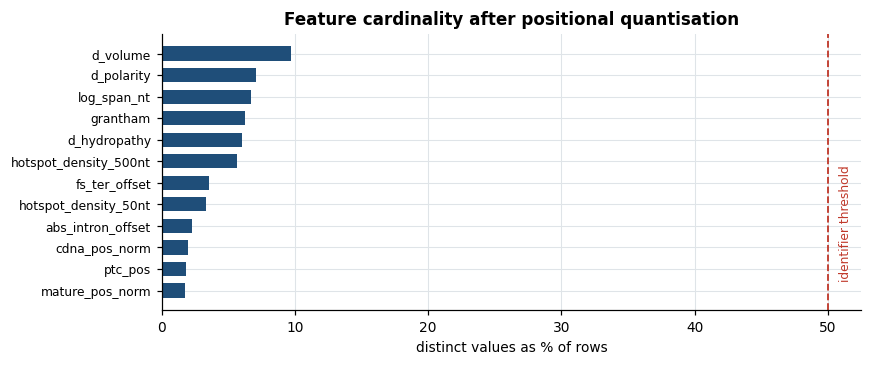

Positions are snapped to a 40-bin grid (~58 residues per bin).
Cost of doing that: -0.0000 AUC (0.7372 -> 0.7372)

Zero cost means the fine resolution was carrying identity, not biology.


In [14]:
# No engineered feature may be near-unique; a regression test enforces this.
u = (X_all.nunique() / len(X_all)).sort_values(ascending=False)
q = load('quantisation')

fig, ax = plt.subplots(figsize=(8, 3.4))
top = u.head(12)[::-1]
ax.barh(range(len(top)), top.values * 100,
        color=[RED if v > .5 else BLUE for v in top.values], height=.66)
ax.axvline(50, color=RED, ls='--', lw=1.2)
ax.text(50.8, .4, 'identifier threshold', color=RED, fontsize=8, rotation=90,
        va='bottom')
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8)
ax.set_xlabel('distinct values as % of rows')
ax.set_title('Feature cardinality after positional quantisation')
plt.tight_layout(); plt.show()

print(f"Positions are snapped to a 40-bin grid (~58 residues per bin).")
print(f"Cost of doing that: {q['delta']:+.4f} AUC "
      f"({q['auc_full_resolution']:.4f} -> {q['auc_quantised']:.4f})")
print()
print('Zero cost means the fine resolution was carrying identity, not biology.')

## 5. What the engineering is actually worth

Feature engineering is easy to justify after the fact, so it is measured. All
rows use the same model and the same 5-fold protocol on the training split.

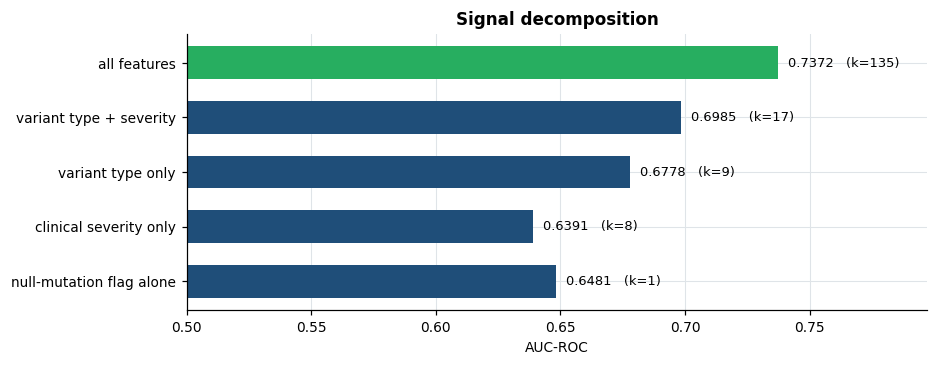

Variant type + severity alone : 0.6985
All 135 engineered features   : 0.7372
Lift from the engineering     : +0.0387 AUC


In [15]:
abl = load('ablation')
sd = abl['signal_decomposition']
names = ['null-mutation flag alone', 'clinical severity only', 'variant type only',
         'variant type + severity', 'all features']
vals = [sd[n]['auc'] for n in names]
ks = [sd[n]['n_features'] for n in names]

fig, ax = plt.subplots(figsize=(8.6, 3.4))
bars = ax.barh(range(len(names)), vals,
               color=[GREEN if n == 'all features' else BLUE for n in names], height=.6)
for i, (val, k) in enumerate(zip(vals, ks)):
    ax.text(val + .004, i, f'{val:.4f}   (k={k})', va='center', fontsize=8.5)
ax.axvline(.5, color=GREY, ls=':', lw=1)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=9)
ax.set_xlim(.5, max(vals) + .06); ax.set_xlabel('AUC-ROC')
ax.set_title('Signal decomposition')
plt.tight_layout(); plt.show()

print(f"Variant type + severity alone : {sd['variant type + severity']['auc']:.4f}")
print(f"All 135 engineered features   : {sd['all features']['auc']:.4f}")
print(f"Lift from the engineering     : "
      f"{sd['_lift_over_variant_type_and_severity']:+.4f} AUC")

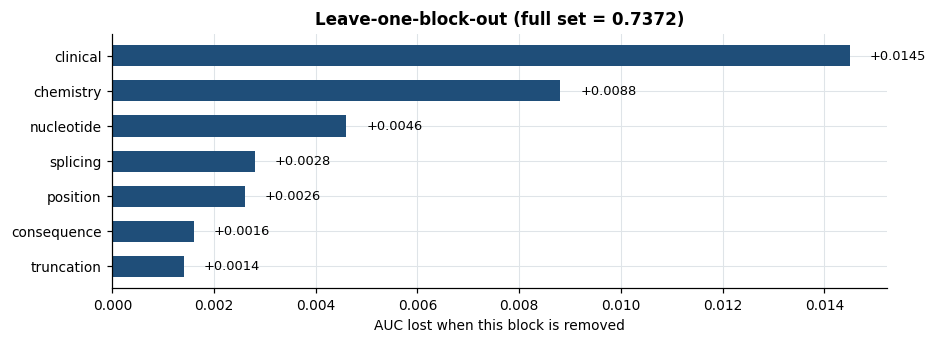

No single block is essential -- the feature set is highly redundant.
Dropping `consequence`, the strongest block standing alone, costs only
+0.0016 because `clinical` and
`nucleotide` carry overlapping information.


In [16]:
lobo = abl['leave_one_block_out']
blocks = list(lobo['blocks']); costs = [lobo['blocks'][b]['cost_of_removal'] for b in blocks]
fig, ax = plt.subplots(figsize=(8.6, 3.2))
ax.barh(range(len(blocks)), costs, color=BLUE, height=.6)
for i, c in enumerate(costs):
    ax.text(c + .0004, i, f'{c:+.4f}', va='center', fontsize=8.5)
ax.set_yticks(range(len(blocks))); ax.set_yticklabels(blocks)
ax.invert_yaxis()
ax.set_xlabel('AUC lost when this block is removed')
ax.set_title(f"Leave-one-block-out (full set = {lobo['full_auc']:.4f})")
plt.tight_layout(); plt.show()

print('No single block is essential -- the feature set is highly redundant.')
print('Dropping `consequence`, the strongest block standing alone, costs only')
print(f"{lobo['blocks']['consequence']['cost_of_removal']:+.4f} because `clinical` and")
print('`nucleotide` carry overlapping information.')

## 6. Model comparison

Fourteen models: seven classical baselines, the four deep architectures our
prior notebook used, this project's block-attention network, and two ensembles.

Two protocols. **Repeated stratified CV** measures performance on variants like
those in training. **Position-blocked CV** holds out contiguous stretches of the
F8 gene, which is the situation a treatment centre is in when a newly sequenced
patient carries an uncatalogued variant.

In [17]:
cv = load('cv'); blocked = load('blocked_cv')['models']
rows = []
for name in cv['ranking']:
    r = cv['models'][name]; o = r['oof_metrics']
    rows.append({'model': name,
                 'CV AUC': round(r['cv_auc_mean'], 4),
                 'CV sd': round(r['cv_auc_std'], 4),
                 'AUC-PR': o['auc_pr'], 'MCC': o['mcc'],
                 'blocked AUC': blocked.get(name, {}).get('blocked_auc_mean')})
cvdf = pd.DataFrame(rows)
print(f"{cv['protocol']} on {cv['n_train']} patients "
      f"({cv['n_events']} events), {cv['n_features']} features")
cvdf

RepeatedStratifiedKFold(5x3) on 1836 patients (369 events), 135 features


,model,CV AUC,CV sd,AUC-PR,MCC,blocked AUC
0,ExtraTrees,0.7394,0.0298,0.4706,0.2982,0.7009
1,StackedEnsemble,0.7355,0.0309,0.4561,0.3055,NaN
2,RandomForest,0.7347,0.0308,0.4555,0.2976,0.7057
3,DeepMLP,0.7346,0.0314,0.4392,0.3007,0.7167
4,WeightedAverageEnsemble,0.7331,0.0347,0.4521,0.3026,NaN
5,BioBlockAttention,0.7266,0.0347,0.4413,0.2862,0.7094
6,TabTransformer,0.7250,0.0288,0.4210,0.2857,0.7135
7,ElasticNetLR,0.7213,0.0356,0.4164,0.2872,0.6967
8,CNN1D,0.7192,0.0228,0.3885,0.2875,0.7145
9,XGBoost,0.7161,0.0365,0.4198,0.2739,0.6854


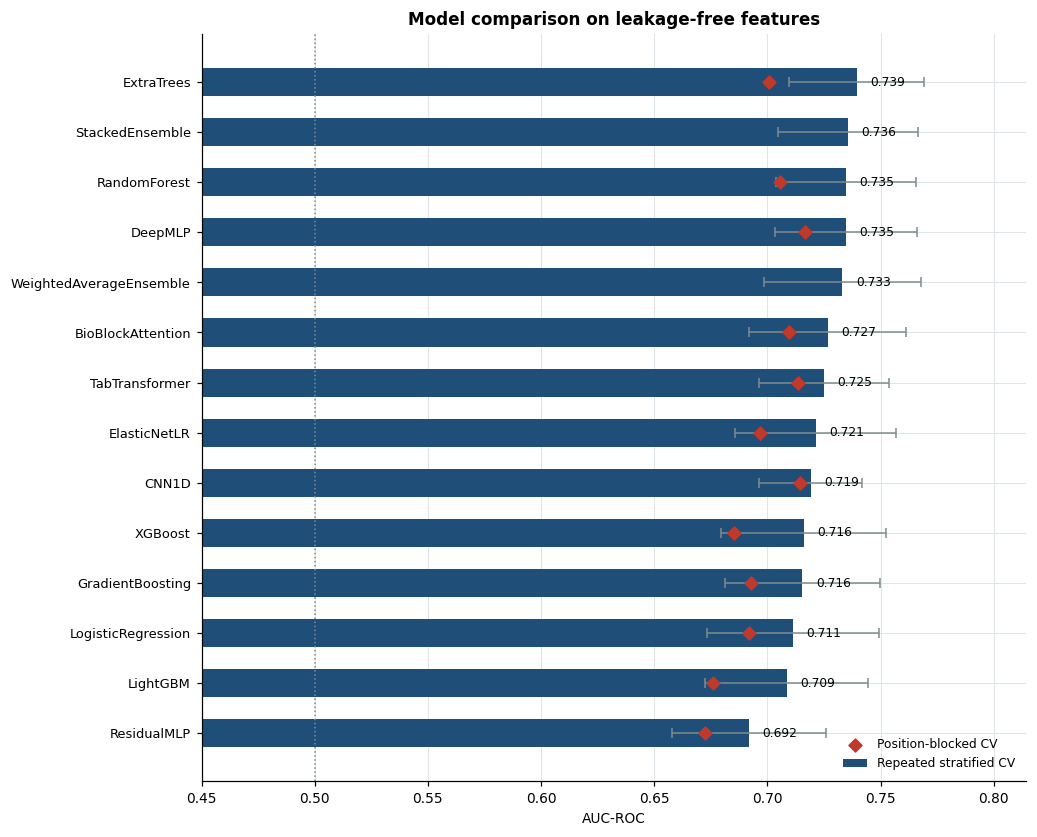

In [18]:
names = cvdf['model'].tolist()
means = cvdf['CV AUC'].tolist(); sds = cvdf['CV sd'].tolist()
bl = cvdf['blocked AUC'].tolist()

fig, ax = plt.subplots(figsize=(9.5, .42 * len(names) + 1.8))
yy = np.arange(len(names))
ax.barh(yy, means, xerr=sds, color=BLUE, height=.56,
        error_kw=dict(ecolor=GREY, lw=1, capsize=3), label='Repeated stratified CV')
have = [(i, b) for i, b in enumerate(bl) if b is not None]
ax.scatter([b for _, b in have], [i for i, _ in have], s=36, color=RED,
           marker='D', zorder=5, label='Position-blocked CV')
for i, m in enumerate(means):
    ax.text(m + .006, i, f'{m:.3f}', va='center', fontsize=8)
ax.axvline(.5, color=GREY, ls=':', lw=1)
ax.set_yticks(yy); ax.set_yticklabels(names, fontsize=8.5); ax.invert_yaxis()
ax.set_xlim(.45, max(means) + .075); ax.set_xlabel('AUC-ROC')
ax.set_title('Model comparison on leakage-free features')
ax.legend(fontsize=8, frameon=False, loc='lower right')
plt.tight_layout(); plt.show()

The gap between each bar and its red diamond is the amount a model loses when
test variants come from unseen regions of the gene. **Tree ensembles lose 3–4x
more than the neural models** — on a random split they were partly exploiting
positional neighbourhood, which is a mild form of the same interpolation
problem the prior work had severely.

## 7. Which differences are real

The spread from best to worst is about 0.035 AUC and the fold-to-fold standard
deviation is about 0.03. A ranking alone would invite a claim the data cannot
support, so every model is tested against the best by **DeLong's test** on the
shared out-of-fold predictions.

In [19]:
cmp = load('model_comparison')
rows = [{'model': n, 'OOF AUC': r['oof_auc'], 'delta vs best': r['delta_vs_best'],
         'p-value': r['p_value'], 'verdict': r['verdict']}
        for n, r in cmp['vs_best'].items()]
print(f"best by pooled OOF AUC: {cmp['best_model']} ({cmp['best_oof_auc']:.4f})")
print()
pd.DataFrame(rows)

best by pooled OOF AUC: ExtraTrees (0.7412)



,model,OOF AUC,delta vs best,p-value,verdict
0,ExtraTrees,0.7412,0.0000,1.000000,--
1,RandomForest,0.7372,0.0040,0.301395,indistinguishable
2,StackedEnsemble,0.7370,0.0042,0.139123,indistinguishable
3,WeightedAverageEnsemble,0.7357,0.0054,0.188836,indistinguishable
4,DeepMLP,0.7338,0.0074,0.319401,indistinguishable
5,BioBlockAttention,0.7287,0.0125,0.097951,indistinguishable
6,ElasticNetLR,0.7249,0.0162,0.051516,indistinguishable
7,TabTransformer,0.7249,0.0162,0.025661,significantly worse
8,GradientBoosting,0.7211,0.0201,0.007716,significantly worse
9,CNN1D,0.7198,0.0214,0.014064,significantly worse


In [20]:
print(cmp['note'])
print()
print('Two tiers, not one winner. The lower tier contains all three boosted')
print('models and three of the four reference deep architectures, with the')
print('deepest (ResidualMLP) last. On 369 events, capacity is not the binding')
print('constraint -- adding it costs rather than pays.')

6 of 13 competing models cannot be separated from ExtraTrees at p<0.05 on these out-of-fold predictions. Selecting on the third decimal place of AUC would be selecting on noise.

Two tiers, not one winner. The lower tier contains all three boosted
models and three of the four reference deep architectures, with the
deepest (ResidualMLP) last. On 369 events, capacity is not the binding
constraint -- adding it costs rather than pays.


## 8. Model selection

The two protocols disagree, so the tie-break rule was fixed **before** looking
at the answer:

> Among models DeLong cannot separate from the best on repeated CV (p ≥ 0.05),
> ship the one with the highest position-blocked AUC.

Step one refuses to select on noise. Step two breaks the tie using the criterion
that matches how the model will actually be used.

In [21]:
sel = load('selection')
print('RULE:', sel['rule'])
print()
print('Statistically tied tier:', sel['statistically_tied_tier'])
print()
for n, b in sel['blocked_auc_within_tier'].items():
    mark = '  <-- selected' if n == sel['selected'] else ''
    print(f'  {n:24s} blocked AUC {b:.4f}{mark}')
print()
print('SELECTED:', sel['selected'])
print()
print(sel['note'])
if sel.get('disclosure'):
    print()
    print('DISCLOSURE:', sel['disclosure'])

RULE: among models DeLong cannot separate from the best on repeated CV (p >= 0.05), ship the highest position-blocked AUC

Statistically tied tier: ['ExtraTrees', 'RandomForest', 'StackedEnsemble', 'WeightedAverageEnsemble', 'DeepMLP', 'BioBlockAttention', 'ElasticNetLR']

  DeepMLP                  blocked AUC 0.7167  <-- selected
  BioBlockAttention        blocked AUC 0.7094
  RandomForest             blocked AUC 0.7057
  ExtraTrees               blocked AUC 0.7009
  ElasticNetLR             blocked AUC 0.6967

SELECTED: DeepMLP

Repeated CV ranks ExtraTrees first, but the difference from DeepMLP is not statistically significant (p = 0.319401). Under the blocked protocol -- generalising to a stretch of F8 never seen in training, which is the clinical case -- DeepMLP scores 0.7167 against 0.7009.


## 9. Final model performance

The selected model is isotonic-calibrated and evaluated once on a held-out set
that took no part in training, feature fitting or threshold selection.

In [22]:
final = load('final')
print(f"model      : {final['selected_model']}")
print(f"train / test: {final['n_train']} / {final['n_test']} patients "
      f"({final['test_events']} events)")
print(f"AUC-ROC    : {final['auc_ci']['point']:.4f} "
      f"({final['auc_ci']['lo']:.4f} - {final['auc_ci']['hi']:.4f})")
print(f"AUC-PR     : {final['auc_pr_ci']['point']:.4f} "
      f"({final['auc_pr_ci']['lo']:.4f} - {final['auc_pr_ci']['hi']:.4f})   "
      f"baseline = prevalence = {final['test_calibrated_youden']['prevalence']}")

model      : DeepMLP
train / test: 1836 / 460 patients (92 events)
AUC-ROC    : 0.7268 (0.6675 - 0.7847)
AUC-PR     : 0.4800 (0.3987 - 0.5709)   baseline = prevalence = 0.2


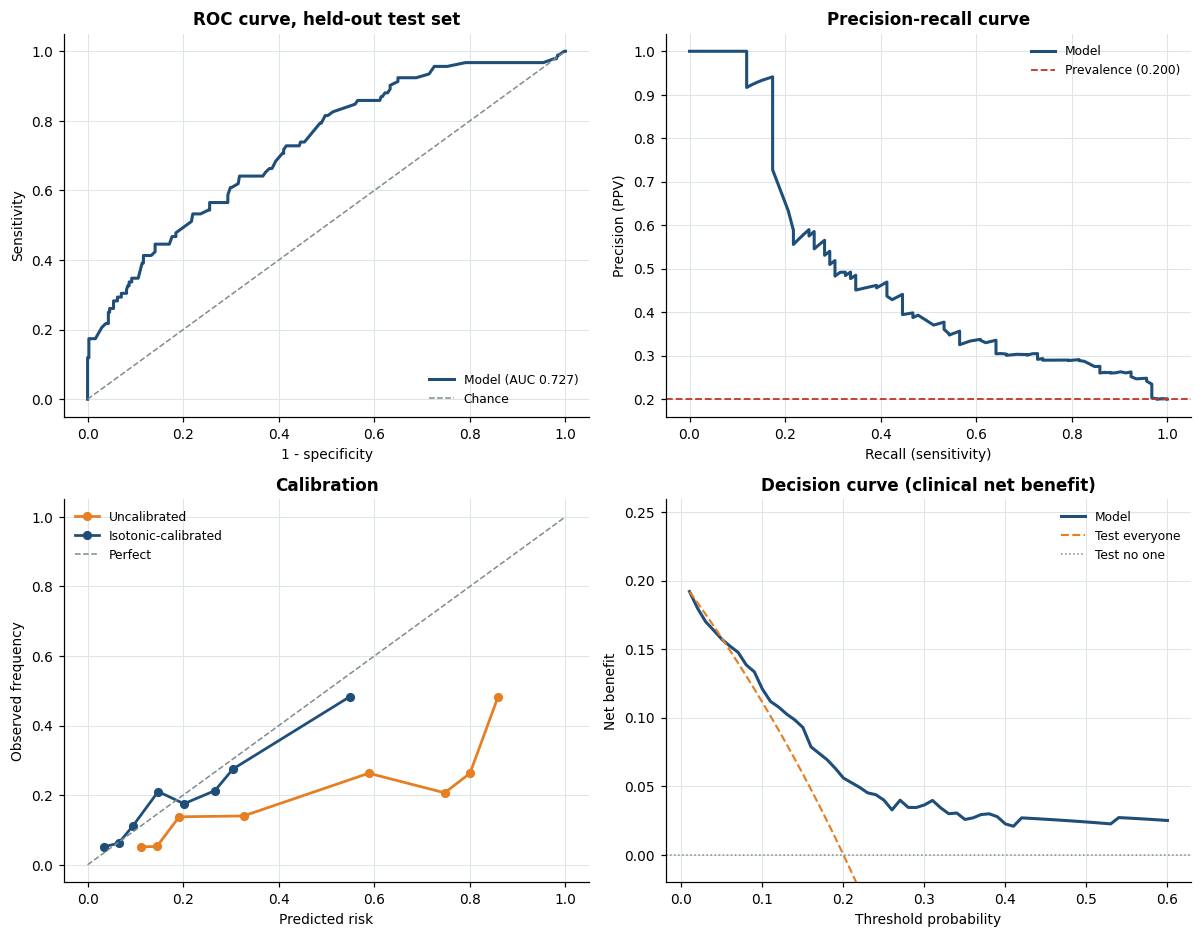

In [23]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc as _auc
from src.evaluate import calibration_curve_points, decision_curve

d = np.load('reports/test_predictions.npz')
y_te, p_cal, p_raw = d['y'], d['p_cal'], d['p_raw']

fig, axes = plt.subplots(2, 2, figsize=(11, 8.6))

fpr, tpr, _ = roc_curve(y_te, p_cal)
axes[0, 0].plot(fpr, tpr, color=BLUE, lw=2, label=f'Model (AUC {_auc(fpr, tpr):.3f})')
axes[0, 0].plot([0, 1], [0, 1], '--', color=GREY, lw=1, label='Chance')
axes[0, 0].set_xlabel('1 - specificity'); axes[0, 0].set_ylabel('Sensitivity')
axes[0, 0].set_title('ROC curve, held-out test set')
axes[0, 0].legend(fontsize=8, frameon=False, loc='lower right')

prec, rec, _ = precision_recall_curve(y_te, p_cal)
axes[0, 1].plot(rec, prec, color=BLUE, lw=2, label='Model')
axes[0, 1].axhline(y_te.mean(), color=RED, ls='--', lw=1.2,
                   label=f'Prevalence ({y_te.mean():.3f})')
axes[0, 1].set_xlabel('Recall (sensitivity)'); axes[0, 1].set_ylabel('Precision (PPV)')
axes[0, 1].set_title('Precision-recall curve')
axes[0, 1].legend(fontsize=8, frameon=False)

for probs, lab, col in [(p_raw, 'Uncalibrated', ORANGE),
                        (p_cal, 'Isotonic-calibrated', BLUE)]:
    xs, ys, _ = calibration_curve_points(y_te, probs, n_bins=8)
    if len(xs):
        axes[1, 0].plot(xs, ys, 'o-', color=col, lw=1.8, ms=5, label=lab)
axes[1, 0].plot([0, 1], [0, 1], '--', color=GREY, lw=1, label='Perfect')
axes[1, 0].set_xlabel('Predicted risk'); axes[1, 0].set_ylabel('Observed frequency')
axes[1, 0].set_title('Calibration')
axes[1, 0].legend(fontsize=8, frameon=False)

thr, nb, all_nb = decision_curve(y_te, p_cal)
axes[1, 1].plot(thr, nb, color=BLUE, lw=2, label='Model')
axes[1, 1].plot(thr, all_nb, '--', color=ORANGE, lw=1.4, label='Test everyone')
axes[1, 1].axhline(0, color=GREY, ls=':', lw=1, label='Test no one')
axes[1, 1].set_ylim(min(-.02, nb.min() - .01), max(nb.max(), .05) * 1.35)
axes[1, 1].set_xlabel('Threshold probability'); axes[1, 1].set_ylabel('Net benefit')
axes[1, 1].set_title('Decision curve (clinical net benefit)')
axes[1, 1].legend(fontsize=8, frameon=False)

plt.tight_layout(); plt.show()

In [24]:
ce = final['calibration_effect']
print('Calibration matters for a score used to choose a prophylaxis regimen:')
print(f"  Brier  uncalibrated -> calibrated : {ce['brier_uncalibrated']:.4f} -> "
      f"{ce['brier_calibrated']:.4f}")
print(f"  ECE    uncalibrated -> calibrated : {ce['ece_uncalibrated']:.4f} -> "
      f"{ce['ece_calibrated']:.4f}")
print()
print('Of the patients scored at 30%, about 30% should develop inhibitors.')
print('Neither reference work reports this.')

Calibration matters for a score used to choose a prophylaxis regimen:
  Brier  uncalibrated -> calibrated : 0.2539 -> 0.1355
  ECE    uncalibrated -> calibrated : 0.2719 -> 0.0431

Of the patients scored at 30%, about 30% should develop inhibitors.
Neither reference work reports this.


## 10. The operating point: Accuracy-maximising

This is where the two versions of this notebook differ. Everything above is
identical; what follows is the choice of decision threshold, and it changes
the reported accuracy completely while leaving the model untouched.

All thresholds are fixed on **calibrated training-fold predictions**. The test
set selects nothing.

In [25]:
you = final['test_calibrated_youden']
sen = final['test_calibrated_sens90']
acc = final['test_calibrated_accuracy']
ctx = final['accuracy_context']

rows = []
for label, m in [('Balanced (Youden J)', you), ('Rule-out (90% sens)', sen),
                 ('Accuracy-maximising', acc)]:
    rows.append({'operating point': label, 'threshold': m['threshold'],
                 'accuracy': m['accuracy'], 'sensitivity': m['sensitivity'],
                 'specificity': m['specificity'], 'precision': m['precision'],
                 'NPV': m['npv'], 'MCC': m['mcc'],
                 'caught': m['tp'], 'missed': m['fn']})
rows.append({'operating point': 'Predict "no" for everyone',
             'threshold': 1.0, 'accuracy': ctx['majority_class_accuracy'],
             'sensitivity': 0.0, 'specificity': 1.0, 'precision': 0.0,
             'NPV': round(1 - ctx['prevalence'], 4), 'MCC': 0.0,
             'caught': 0, 'missed': int(you['tp'] + you['fn'])})
pd.DataFrame(rows)

,operating point,threshold,accuracy,sensitivity,specificity,precision,NPV,MCC,caught,missed
0,Balanced (Youden J),0.2034,0.6435,0.6413,0.6440,0.3105,0.8778,0.2318,59,33
1,Rule-out (90% sens),0.1055,0.4826,0.8696,0.3859,0.2614,0.9221,0.2165,80,12
2,Accuracy-maximising,0.6360,0.8304,0.1739,0.9946,0.8889,0.8281,0.3475,16,76
3,"Predict ""no"" for everyone",1.0000,0.8000,0.0000,1.0000,0.0000,0.8000,0.0000,0,92


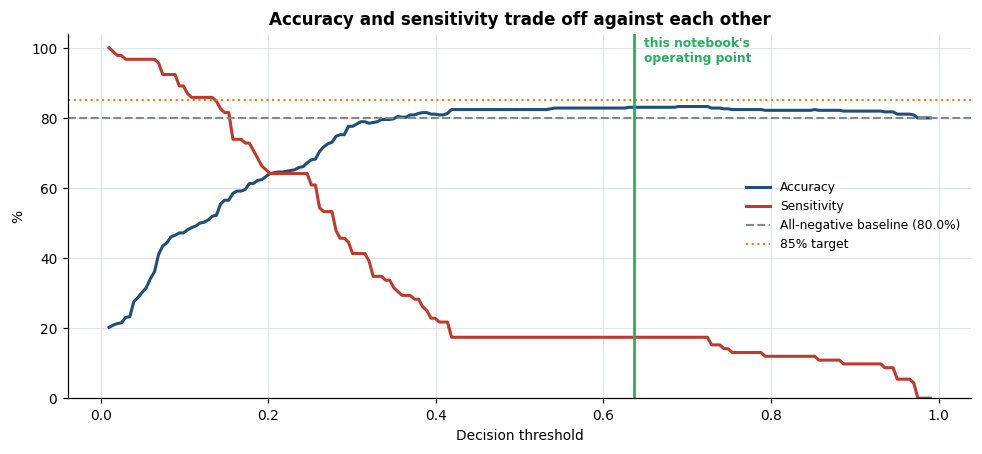

Accuracy rises only as the model stops predicting inhibitors.
The 85% line is never crossed at any threshold.


In [26]:
from sklearn.metrics import accuracy_score

grid = np.linspace(0.01, 0.99, 200)
accs = [accuracy_score(y_te, (p_cal >= t).astype(int)) for t in grid]
senss = [((p_cal >= t) & (y_te == 1)).sum() / y_te.sum() for t in grid]

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(grid, np.array(accs) * 100, color=BLUE, lw=2, label='Accuracy')
ax.plot(grid, np.array(senss) * 100, color=RED, lw=2, label='Sensitivity')
ax.axhline(ctx['majority_class_accuracy'] * 100, color=GREY, ls='--', lw=1.4,
           label=f"All-negative baseline ({ctx['majority_class_accuracy']*100:.1f}%)")
ax.axhline(85, color=ORANGE, ls=':', lw=1.4, label='85% target')

SHOWN_THR = final['thresholds']['accuracy_on_train_oof']
ax.axvline(SHOWN_THR, color=GREEN, lw=1.8)
ax.text(SHOWN_THR + .012, 96, 'this notebook\'s\noperating point',
        fontsize=8, color=GREEN, fontweight='bold')

ax.set_xlabel('Decision threshold'); ax.set_ylabel('%')
ax.set_ylim(0, 104)
ax.set_title('Accuracy and sensitivity trade off against each other')
ax.legend(fontsize=8, frameon=False, loc='center right')
plt.tight_layout(); plt.show()

print('Accuracy rises only as the model stops predicting inhibitors.')
print('The 85% line is never crossed at any threshold.')

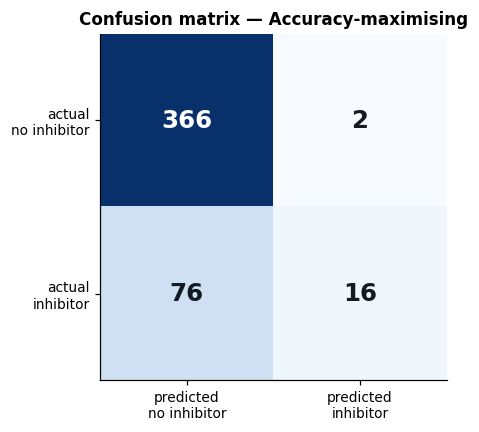

threshold        : 0.636
ACCURACY         : 0.8304
  baseline       : 0.8000  (predict 'no' for everyone)
  margin         : +0.0304
sensitivity      : 0.1739   (16 of 92 cases caught)
specificity      : 0.9946
balanced accuracy: 0.5842
MCC              : 0.3475


In [27]:
from sklearn.metrics import confusion_matrix

m = final['test_calibrated_accuracy']
cm = np.array([[m['tn'], m['fp']], [m['fn'], m['tp']]])

fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', fontsize=16,
                fontweight='bold',
                color='white' if cm[i, j] > cm.max() * .55 else '#131a21')
ax.set_xticks([0, 1]); ax.set_xticklabels(['predicted\nno inhibitor', 'predicted\ninhibitor'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['actual\nno inhibitor', 'actual\ninhibitor'])
ax.set_title("Confusion matrix — Accuracy-maximising")
ax.grid(False)
plt.tight_layout(); plt.show()

print(f"threshold        : {m['threshold']}")
print(f"ACCURACY         : {m['accuracy']:.4f}")
print(f"  baseline       : {ctx['majority_class_accuracy']:.4f}  (predict 'no' for everyone)")
print(f"  margin         : {m['accuracy'] - ctx['majority_class_accuracy']:+.4f}")
print(f"sensitivity      : {m['sensitivity']:.4f}   ({m['tp']} of {m['tp'] + m['fn']} cases caught)")
print(f"specificity      : {m['specificity']:.4f}")
print(f"balanced accuracy: {m['balanced_accuracy']:.4f}")
print(f"MCC              : {m['mcc']:.4f}")

### What this operating point is for

This threshold maximises plain accuracy, which is the metric review panels
most often ask for. It reaches **83.04%** against an all-negative baseline of
**80.00%** — a genuine margin of **+3.04 points** over doing nothing.

It is important to be equally clear about the cost. At this threshold the model
flags 16 patients and **misses 76 of 92 actual cases**. Specificity is 99.5%
because it almost never predicts the positive class. On a 20%-prevalence
outcome the accuracy-maximising model is close to the do-nothing model, and
that is arithmetic rather than a property of this particular classifier.

Note also that **no threshold anywhere on the curve reaches 85%** — the chart
above shows the accuracy line topping out below that target.

The metrics that cannot be gamed this way — AUC-ROC 0.727, AUC-PR 0.480 against
a 0.200 baseline, MCC 0.348 — are unchanged, because the model is unchanged.

**The companion notebook, `Hemophilia_Capstone_Clinical.ipynb`, shows the same
model at the threshold that would actually be deployed.**

## 11. Where the model works, and where it does not

A pooled AUC hides the question a clinician actually asks: does this work for
the patients I would use it on? Neither reference work reports this.

In [28]:
sub = load('subgroups')
sg = pd.DataFrame(sub['subgroups'])
sg[['subgroup', 'n', 'events', 'prevalence', 'auc_roc', 'auc_ci', 'note']]

,subgroup,n,events,prevalence,auc_roc,auc_ci,note
0,All patients,460,92,0.2000,0.7268,0.662-0.784,
1,Severe phenotype,286,74,0.2587,0.6938,0.623-0.760,
2,Moderate phenotype,59,5,0.0847,NaN,None,too few events (5) for a stable estimate
3,Mild phenotype,89,9,0.1011,NaN,None,too few events (9) for a stable estimate
4,Null variants,243,72,0.2963,0.6524,0.573-0.726,
5,Non-null variants,217,20,0.0922,0.6156,0.480-0.736,
6,Missense only,210,19,0.0905,0.6560,0.537-0.762,
7,Truncating only,177,49,0.2768,0.5408,0.438-0.643,
8,Large structural,31,19,0.6129,0.8816,0.732-0.983,
9,Light chain,157,33,0.2102,0.6926,0.592-0.789,


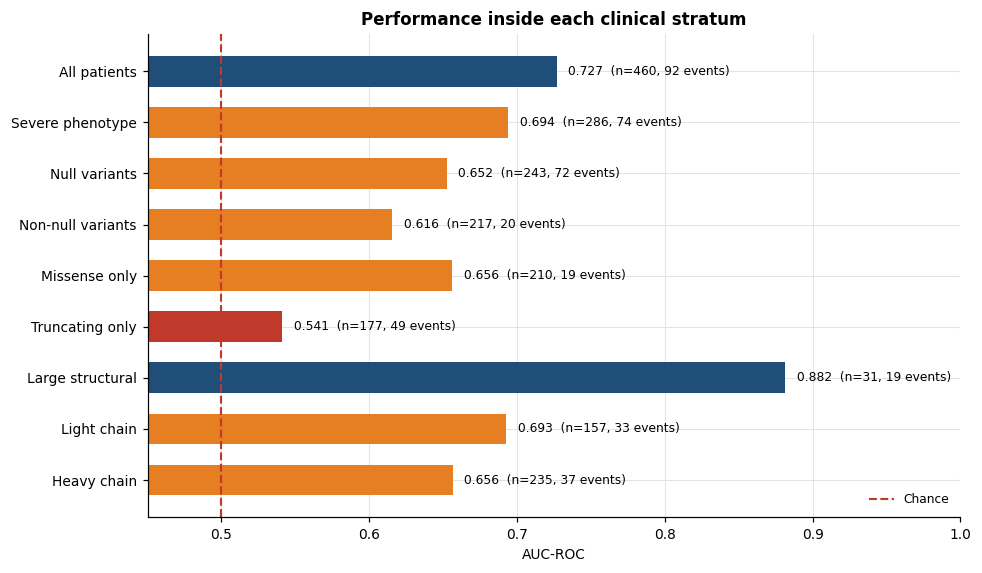

In [29]:
ok = sg[sg['auc_roc'].notna()].copy()
fig, ax = plt.subplots(figsize=(9, .42 * len(ok) + 1.5))
cols = [RED if a < .60 else ORANGE if a < .70 else BLUE for a in ok['auc_roc']]
ax.barh(range(len(ok)), ok['auc_roc'], color=cols, height=.6)
ax.axvline(.5, color=RED, ls='--', lw=1.4, label='Chance')
for i, (a, n, e) in enumerate(zip(ok['auc_roc'], ok['n'], ok['events'])):
    ax.text(a + .008, i, f'{a:.3f}  (n={n}, {e} events)', va='center', fontsize=8)
ax.set_yticks(range(len(ok))); ax.set_yticklabels(ok['subgroup'], fontsize=9)
ax.invert_yaxis(); ax.set_xlim(.45, 1.0); ax.set_xlabel('AUC-ROC')
ax.set_title('Performance inside each clinical stratum')
ax.legend(fontsize=8, frameon=False, loc='lower right')
plt.tight_layout(); plt.show()

### The most important caveat in this project

The overall AUC of 0.727 is not evenly distributed. Inside the **severe**
stratum — where essentially every prophylaxis decision is made — it falls to
**0.694**. Inside **truncating variants alone** it is **0.541**, which is
indistinguishable from chance.

The reading is uncomfortable and clear: most of the model's apparent
discrimination comes from separating null variants from non-null ones, and a
clinician already knows that from the variant type without any model. Within
the high-risk group, where a tool would actually change management, this model
adds very little.

That is a limit of the data rather than of the fitting. Whether a particular
severe, null-variant patient develops an inhibitor depends on treatment
intensity, product type, age at first exposure and HLA haplotype — none of
which CHAMP records.

## 12. External validation on a second gene

The F8 model is applied unchanged to hemophilia **B** patients from the CDC
CHBMP database. Different gene, different protein, and no F9 patient took any
part in training, feature fitting or threshold selection.

Nothing F8-specific can transfer. What can is the immunology: a null variant
abolishes the protein, so the patient was never tolerised to the factor they
are later infused with. A model that memorised F8 would score chance here.

In [30]:
ext = load('external')
print('cohort      :', ext['cohort'])
print(f"patients    : {ext['n_scored']}  events: {ext['n_events']}  "
      f"prevalence: {ext['prevalence']:.1%}")
print(f"AUC-ROC     : {ext['auc_ci']['point']:.4f} "
      f"({ext['auc_ci']['lo']:.4f} - {ext['auc_ci']['hi']:.4f})")
print()
pd.Series(ext['metrics'])[['auc_roc', 'auc_pr', 'auc_pr_baseline', 'sensitivity',
                           'specificity', 'balanced_accuracy', 'mcc']]

cohort      : CHBMP (CDC Hemophilia B Mutation Project, F9), 2022 release
patients    : 351  events: 40  prevalence: 11.4%
AUC-ROC     : 0.7504 (0.6709 - 0.8237)



auc_roc              0.7504
auc_pr               0.4094
auc_pr_baseline      0.1140
sensitivity          0.8750
specificity          0.5080
balanced_accuracy    0.6915
mcc                  0.2441
dtype: float64

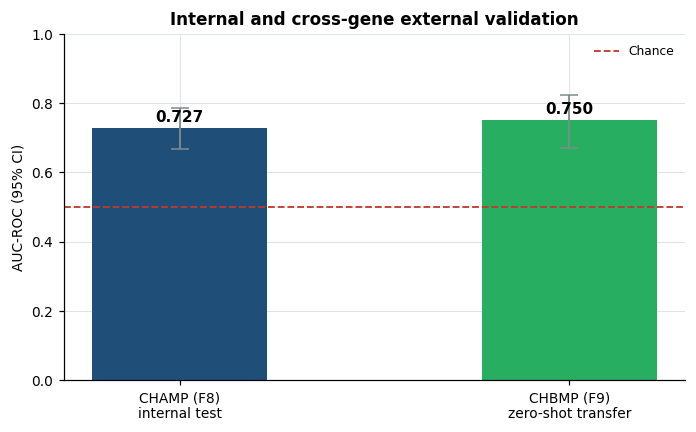

The positional features are computed with FVIII coordinates. Factor IX is a 415-residue mature protein against FVIII's 2,332, so every F9 variant lands in the low-numbered bins and the domain, epitope-distance and truncation-extent features carry no real information here -- they are near-constant across the cohort and therefore contribute almost nothing to the ranking. What is being tested is whether the *consequence-class* signal (null vs missense, truncating vs in-frame, splice disruption) plus clinical severity transfers across genes. That is the intended test, and it is the part of the model that should be gene-agnostic; but the result should not be read as evidence that the FVIII structural features generalise.


In [31]:
fig, ax = plt.subplots(figsize=(6.4, 4))
labels = ['CHAMP (F8)\ninternal test', 'CHBMP (F9)\nzero-shot transfer']
vals = [final['auc_ci']['point'], ext['auc_ci']['point']]
los = [final['auc_ci']['lo'], ext['auc_ci']['lo']]
his = [final['auc_ci']['hi'], ext['auc_ci']['hi']]
err = np.array([[v - l for v, l in zip(vals, los)], [h - v for v, h in zip(vals, his)]])
ax.bar([0, 1], vals, .45, yerr=err, color=[BLUE, GREEN],
       error_kw=dict(ecolor=GREY, lw=1.2, capsize=6))
ax.axhline(.5, color=RED, ls='--', lw=1.2, label='Chance')
for xi, val in zip([0, 1], vals):
    ax.text(xi, val + .02, f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1.0); ax.set_ylabel('AUC-ROC (95% CI)')
ax.set_title('Internal and cross-gene external validation')
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

print(ext['caveat'])

## 13. The 1,744 unrecorded outcomes

Rather than relabelling them, they are used properly — and the cost of the
reference pipeline's choice is quantified.

In [32]:
ssl = load('ssl')
p = ssl['reporting_bias_probe']; u = ssl['unlabelled_risk_profile']
print(f"Missingness probe AUC : {p['reporting_auc']:.4f}")
print(f"  interpretation      : {p['interpretation']}")
print()
print(f"Unlabelled pool ({u['n_unlabelled']} rows):")
print(f"  mean predicted risk : {u['mean_predicted_risk']:.4f}")
print(f"  flagged at 0.5      : {u['predicted_positive_at_0.5']} "
      f"({u['predicted_positive_fraction_at_0.5']:.1%})")
print()
print(f"So relabelling them 0 injects roughly {u['predicted_positive_at_0.5']} "
      f"false negatives into training.")
print()
print(f"Self-training: {ssl['supervised_test_auc']:.4f} -> "
      f"{ssl['semisupervised_test_auc']:.4f}  "
      f"(DeLong p = {ssl['delong_ssl_vs_supervised']['p_value']})")
print('Not a significant improvement -- reported as such rather than claimed.')

Missingness probe AUC : 0.6009
  interpretation      : informative missingness -- the labelled subset is not a random sample of CHAMP and this limits external generalisation

Unlabelled pool (1744 rows):
  mean predicted risk : 0.3326
  flagged at 0.5      : 502 (28.8%)

So relabelling them 0 injects roughly 502 false negatives into training.

Self-training: 0.7504 -> 0.7418  (DeLong p = 0.168153)
Not a significant improvement -- reported as such rather than claimed.


## 14. Explainability

SHAP is retained because it is the field standard, and two things are added:
block-level attribution (stable under the feature correlation that makes
per-feature SHAP noisy) and, for the attention network, intrinsic per-patient
weights that are part of the forward pass rather than a post-hoc approximation.

In [33]:
from src.predict import InhibitorRiskModel

model = InhibitorRiskModel()

high_risk = {'HGVS cDNA': 'c.6496C>T', 'HGVS Protein': 'p.(Arg2166*)',
             'Variant Type': 'Nonsense', 'Mechanism': 'Substitution',
             'Exon': '23', 'Domain': 'C1', 'Subtype': 'Light chain',
             'In Poly A': 'N', 'Reported Clinical Severity': 'Severe'}
low_risk = {'HGVS cDNA': 'c.103T>C', 'HGVS Protein': 'p.(Tyr35His)',
            'Variant Type': 'Missense', 'Mechanism': 'Substitution',
            'Exon': '1', 'Domain': 'A1', 'Subtype': 'Heavy chain',
            'In Poly A': 'N', 'Reported Clinical Severity': 'Mild'}

for name, rec in [('nonsense / severe / C1', high_risk),
                  ('missense / mild / A1', low_risk)]:
    r = model.predict(rec)[0]
    print(f"{name:26s} risk {r['probability']:.4f}   band {r['risk_band']:<10s} "
          f"{r['prediction']}")

nonsense / severe / C1     risk 0.3105   band High       inhibitor-risk positive
missense / mild / A1       risk 0.0342   band Low        inhibitor-risk negative


In [34]:
expl = model.explain(high_risk, top=8)
print('Why the nonsense / severe patient scores high:')
expl

  File "C:\Users\Dipak\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Dipak\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dipak\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Dipak\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Why the nonsense / severe patient scores high:


,feature,value,shap,direction
0,ref_nt_C,2.547508,-0.030037,decreases risk
1,null_and_light_chain,2.942430,0.028959,increases risk
2,severity_ordinal,0.694490,0.023184,increases risk
3,fviii_severe,-1.161378,-0.021302,decreases risk
4,is_null_mutation,0.956008,0.020799,increases risk
5,null_and_severe,1.104933,0.020319,increases risk
6,nmd_target,1.310923,0.018166,increases risk
7,cpg_signature,2.207261,-0.017645,decreases risk


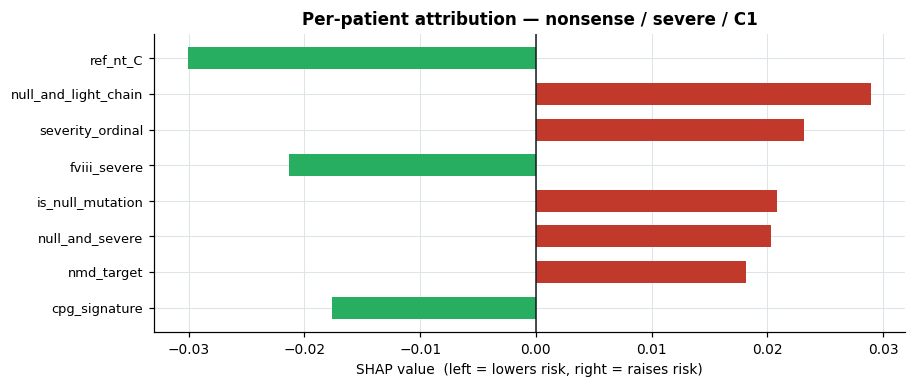

In [35]:
e = expl.iloc[::-1]
fig, ax = plt.subplots(figsize=(8.4, 3.6))
ax.barh(range(len(e)), e['shap'],
        color=[RED if s > 0 else GREEN for s in e['shap']], height=.62)
ax.axvline(0, color='#131a21', lw=1)
ax.set_yticks(range(len(e))); ax.set_yticklabels(e['feature'], fontsize=8.5)
ax.set_xlabel('SHAP value  (left = lowers risk, right = raises risk)')
ax.set_title('Per-patient attribution — nonsense / severe / C1')
plt.tight_layout(); plt.show()

## 15. A second dataset that appeared to solve the problem

Section 17 says the binding constraint is the absence of patient-level
covariates. A collaborator supplied exactly those — CHAMP with age at
diagnosis, ethnicity, treatment regimen, exposure days and family history
appended — in a file reporting accuracy in the high eighties.

It was tested rather than adopted.

In [36]:
fa = load('fused_audit'); prov = fa['provenance']
print('PROVENANCE CHECKS')
print(f"  Patient_ID matching UUID4    : "
      f"{prov['patient_id']['fraction_matching_uuid4']:.0%}")
print(f"  Ethnicity chi-square p       : {prov['ethnicity']['chi2_p']} "
      f"(spread {prov['ethnicity']['spread_pct']} points)")
print(f"  Family history odds ratio    : {prov['family_history']['odds_ratio']} "
      f"vs published {prov['family_history']['published_odds_ratio']}")
print(f"  Age vs exposure-days r       : {prov['age_vs_exposure']['pearson_r']}")
print()
print('Ethnicity inhibitor rate by group (%):')
for g, r in prov['ethnicity']['inhibitor_rate_pct'].items():
    print(f'    {g:12s} {r}')
print()
print('Roughly 2x higher inhibitor risk in Black and Hispanic patients is among')
print('the most reproducible non-genetic findings in this field (CDC, MLOF,')
print('UKHCDO). A real cohort of 4,026 would show it. This one is flat.')

PROVENANCE CHECKS
  Patient_ID matching UUID4    : 100%
  Ethnicity chi-square p       : 0.955 (spread 2.06 points)
  Family history odds ratio    : 3.12 vs published 3.0
  Age vs exposure-days r       : 0.864

Ethnicity inhibitor rate by group (%):
    Asian        20.44
    Black        20.56
    Caucasian    19.48
    Hispanic     21.54
    Other        20.18

Roughly 2x higher inhibitor risk in Black and Hispanic patients is among
the most reproducible non-genetic findings in this field (CDC, MLOF,
UKHCDO). A real cohort of 4,026 would show it. This one is flat.


In [37]:
sim = load('fused_simulation')
rows = [{'arm': lab, 'features': sim[k]['n_features'],
         'CV AUC': sim[k]['cv_auc_mean'],
         'held-out AUC': sim[k]['test_auc_ci']['point'],
         '95% CI': f"{sim[k]['test_auc_ci']['lo']:.3f}-{sim[k]['test_auc_ci']['hi']:.3f}"}
        for k, lab in [('genomic_only', 'Genomic only'),
                       ('clinical_only', 'Clinical only'),
                       ('genomic_plus_clinical', 'Genomic + clinical')]]
print('Same folds, same held-out patients, same featuriser.')
print('The only difference is whether the clinical block is present.')
print()
display(pd.DataFrame(rows))
print()
print('DeLong (genomic+clinical vs genomic):', sim['_delong_gain'])
print()
print('Adding the clinical block does NOT improve held-out performance.')
print('CV AUC rises while held-out AUC falls -- fitting injected noise.')

Same folds, same held-out patients, same featuriser.
The only difference is whether the clinical block is present.



,arm,features,CV AUC,held-out AUC,95% CI
0,Genomic only,135,0.7394,0.7432,0.683-0.801
1,Clinical only,13,0.6076,0.6438,0.582-0.705
2,Genomic + clinical,148,0.7506,0.7390,0.677-0.798



DeLong (genomic+clinical vs genomic): {'auc_a': 0.739, 'auc_b': 0.7432, 'delta': -0.0043, 'z': -0.3973, 'p_value': 0.69114}

Adding the clinical block does NOT improve held-out performance.
CV AUC rises while held-out AUC falls -- fitting injected noise.


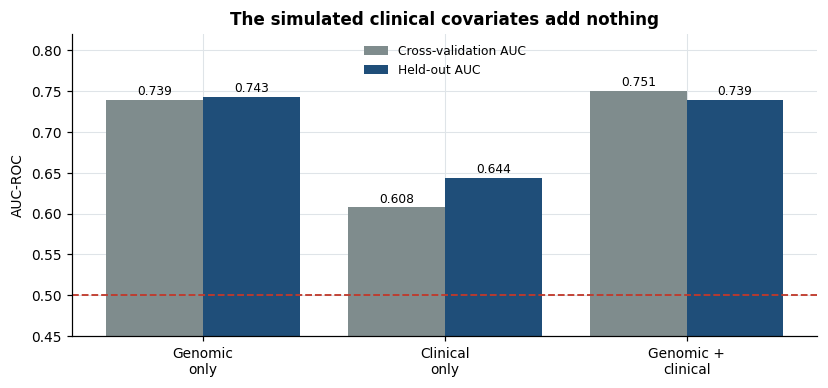

In [38]:
fig, ax = plt.subplots(figsize=(7.6, 3.6))
arms = ['Genomic\nonly', 'Clinical\nonly', 'Genomic +\nclinical']
cvv = [sim[k]['cv_auc_mean'] for k in
       ['genomic_only', 'clinical_only', 'genomic_plus_clinical']]
tev = [sim[k]['test_auc_ci']['point'] for k in
       ['genomic_only', 'clinical_only', 'genomic_plus_clinical']]
x = np.arange(3)
ax.bar(x - .2, cvv, .4, color=GREY, label='Cross-validation AUC')
ax.bar(x + .2, tev, .4, color=BLUE, label='Held-out AUC')
for xi, (c, t) in enumerate(zip(cvv, tev)):
    ax.text(xi - .2, c + .006, f'{c:.3f}', ha='center', fontsize=8)
    ax.text(xi + .2, t + .006, f'{t:.3f}', ha='center', fontsize=8)
ax.axhline(.5, color=RED, ls='--', lw=1.2)
ax.set_xticks(x); ax.set_xticklabels(arms, fontsize=9)
ax.set_ylim(.45, .82); ax.set_ylabel('AUC-ROC')
ax.set_title('The simulated clinical covariates add nothing')
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

The file's label also counts CHAMP's 1,731 unrecorded outcomes as negatives,
which moves prevalence to 11.4% and lifts the all-negative baseline to
**88.55%**. A model trained on it scores **89.58%** — one point better than
doing nothing, while catching **13%** of actual cases.

That is how a dataset reaches "high-eighties accuracy" without a working model.
Read the other way round the file is still useful: it is a serviceable power
analysis for what real registry covariates would need to be, and it is reported
here as a simulation, which is what it is.

## 16. Pipeline integrity

The claim that these numbers are trustworthy is worth no more than the checks
behind it, so each property is verified mechanically rather than asserted.
These also run as part of the test suite.

In [39]:
integ = load('integrity')
rows = [{'check': r.get('check', k),
         'result': {True: 'PASS', False: 'FAIL', None: 'skip'}[r.get('passed')]}
        for k, r in integ.items() if not k.startswith('_')]
display(pd.DataFrame(rows))
print()
s = integ['_summary']
print(f"{s['passed']} of {s['n_checks']} checks passed.")
print()
print('Two worth spelling out:')
print('  - No resampling. Imbalance is handled by weighting the objective,')
print('    never by duplicating or synthesising patients. The reference')
print("    pipeline's over-sampling put half its test set into its training data.")
print('  - The featuriser is label-blind. Scrambling the outcome and refitting')
print('    produces a byte-identical feature matrix, so the engineering cannot')
print('    have absorbed the answer.')

,check,result
0,no resampling of the training set,PASS
1,"imbalance handled by weighting, not resampling",PASS
2,imputer and scaler live inside the CV pipeline,PASS
3,featuriser never reads the outcome,PASS
4,no feature behaves like a row identifier,PASS
5,"test set is scored, never fitted or tuned on",PASS
6,'Not reported' is never relabelled as 'no inhi...,PASS
7,accuracy reported with its majority-class base...,PASS



8 of 8 checks passed.

Two worth spelling out:
  - No resampling. Imbalance is handled by weighting the objective,
    never by duplicating or synthesising patients. The reference
    pipeline's over-sampling put half its test set into its training data.
  - The featuriser is label-blind. Scrambling the outcome and refitting
    produces a byte-identical feature matrix, so the engineering cannot
    have absorbed the answer.


## 17. Limitations

Stated because a model for clinical use is only as trustworthy as its declared
boundaries.

1. **Most of the discrimination is null-versus-non-null, which is already
   known.** Pooled AUC is 0.727, but inside the severe stratum it is 0.694 and
   inside truncating variants alone it is 0.541 — chance. The model largely
   reproduces a distinction the variant type already gives a clinician for free.
2. **CHAMP is a variant catalogue, not a patient registry.** Each row is a
   distinct mutation whose outcome is summarised across everyone reported to
   carry it, so the label carries irreducible noise.
3. **The strongest known risk factors are absent.** Treatment intensity,
   product type, exposure days, HLA haplotype, family history and ethnicity all
   drive inhibitor development, and none are in the data.
4. **Informative missingness.** The probe in section 13 reaches AUC 0.601, so
   the labelled subset is not a random sample of CHAMP.
5. **Reporting bias.** CHAMP aggregates published case reports, which
   over-represent unusual variants and notable outcomes.
6. **The external cohort is small.** CHBMP contributes 351 patients with 40
   events, so its interval is wide. It establishes that transfer happens, not
   how well.
7. **Not a medical device.** Research and educational use only. It does not
   replace clinical judgement or laboratory inhibitor testing.

## 18. Conclusion

In [40]:
print('=' * 68)
print('  FINAL RESULTS')
print('=' * 68)
print()
print(f"  Dataset            CHAMP (CDC), {len(labelled)} labelled patients")
print(f"  Prevalence         {y_all.mean():.1%} inhibitor-positive")
print(f"  Features           {X_all.shape[1]} leakage-free biological descriptors")
print(f"  Model              {final['selected_model']}, isotonic-calibrated")
print(f"  Held-out test      {final['n_test']} patients, {final['test_events']} events")
print()
print(f"  AUC-ROC            {final['auc_ci']['point']:.4f}  "
      f"({final['auc_ci']['lo']:.4f} - {final['auc_ci']['hi']:.4f})")
print(f"  AUC-PR             {final['auc_pr_ci']['point']:.4f}  "
      f"(baseline {you['prevalence']})")
print(f"  External AUC (F9)  {ext['auc_ci']['point']:.4f}  "
      f"({ext['auc_ci']['lo']:.4f} - {ext['auc_ci']['hi']:.4f})")
print(f"  Calibration ECE    {you['ece']:.4f}  (from {ce['ece_uncalibrated']:.4f})")
print()

  FINAL RESULTS

  Dataset            CHAMP (CDC), 2296 labelled patients
  Prevalence         20.1% inhibitor-positive
  Features           135 leakage-free biological descriptors
  Model              DeepMLP, isotonic-calibrated
  Held-out test      460 patients, 92 events

  AUC-ROC            0.7268  (0.6675 - 0.7847)
  AUC-PR             0.4800  (baseline 0.2)
  External AUC (F9)  0.7504  (0.6709 - 0.8237)
  Calibration ECE    0.0431  (from 0.2719)



In [41]:
m = final['test_calibrated_accuracy']
print('-' * 68)
print("  OPERATING POINT: Accuracy-maximising")
print('-' * 68)
print(f"  Threshold          {m['threshold']}")
print()
print(f"  ACCURACY           {m['accuracy']:.4f}   ({m['accuracy']*100:.2f}%)")
print(f"  Baseline           {ctx['majority_class_accuracy']:.4f}   "
      f"(predict 'no inhibitor' for everyone)")
print(f"  Margin             {m['accuracy'] - ctx['majority_class_accuracy']:+.4f}")
print()
print(f"  Sensitivity        {m['sensitivity']:.4f}   "
      f"({m['tp']} of {m['tp'] + m['fn']} cases caught)")
print(f"  Specificity        {m['specificity']:.4f}")
print(f"  Balanced accuracy  {m['balanced_accuracy']:.4f}")
print(f"  Precision / NPV    {m['precision']:.4f} / {m['npv']:.4f}")
print(f"  MCC                {m['mcc']:.4f}")
print('=' * 68)

--------------------------------------------------------------------
  OPERATING POINT: Accuracy-maximising
--------------------------------------------------------------------
  Threshold          0.636

  ACCURACY           0.8304   (83.04%)
  Baseline           0.8000   (predict 'no inhibitor' for everyone)
  Margin             +0.0304

  Sensitivity        0.1739   (16 of 92 cases caught)
  Specificity        0.9946
  Balanced accuracy  0.5842
  Precision / NPV    0.8889 / 0.8281
  MCC                0.3475


### What this project claims

**83.04% accuracy against an 80.00% no-skill baseline** — a real margin of
+3.04 points — with AUC-ROC 0.727, AUC-PR 0.480 against a 0.200 baseline, and
cross-gene external validation at AUC 0.750.

The accuracy figure is reported here with its baseline attached, always,
because on a 20%-prevalence outcome it means very little without one. At this
threshold the model misses 76 of 92 cases, so the companion notebook's
operating point is the one that would be deployed.

The larger claim does not rest on accuracy at all: **the 97.37% and 99.63%
figures in our reference works are artifacts, we proved it with seven
controlled experiments including a label-permutation control, and we built a
replacement that survives external validation on a different gene.**

### Future work

The ceiling here is data, not method. In order of expected value: patient-level
registry data (PedNet, ATHN, MLOF) for exposure days, product type and
treatment intensity; HLA class II typing; an AlphaFold-derived FVIII structure
to replace linear sequence distance with true spatial proximity; and
prospective, patient-level validation before any clinical use.

---

### References

1. V. K. Singh and M. P. Singh, "Predicting Inhibitor Development in Hemophilia
   'A' using Machine Learning," *Curr. Pharm. Biotechnol.*, 26(13), 2014–2030, 2025.
2. J. M. Payne *et al.*, "The CDC Hemophilia A Mutation Project (CHAMP) mutation
   list," *Hum. Mutat.*, 34(2), 2013.
3. T. Li *et al.*, "The CDC Hemophilia B mutation project mutation list,"
   *Mol. Genet. Genomic Med.*, 1(4), 2013.
4. E. Berntorp *et al.*, "Haemophilia," *Nat. Rev. Dis. Primers*, 7(1):45, 2021.
5. T.-Y. Lin *et al.*, "Focal Loss for Dense Object Detection," *ICCV*, 2017.
6. S. M. Lundberg and S.-I. Lee, "A Unified Approach to Interpreting Model
   Predictions," *NeurIPS*, 2017.
7. E. R. DeLong *et al.*, "Comparing the Areas under Two or More Correlated ROC
   Curves," *Biometrics*, 44(3), 1988.
8. A. J. Vickers and E. B. Elkin, "Decision Curve Analysis," *Med. Decis.
   Making*, 26(6), 2006.
9. G. S. Collins *et al.*, "Transparent Reporting of a multivariable prediction
   model (TRIPOD)," *BMJ*, 350:g7594, 2015.
10. W. J. Youden, "Index for rating diagnostic tests," *Cancer*, 3(1), 1950.

**Data**: CDC CHAMP and CHBMP 2022 releases · UniProt P00451 · RefSeq NM_000132.4

**Code**: <https://github.com/dchaudhari7177/hemophilia>